In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/world-gold-price.csv')

In [7]:
print(f"Dữ liệu gồm {df.shape[0]} hàng và {df.shape[1]} cột")
df.head()

Dữ liệu gồm 3104 hàng và 6 cột


,Price,Open,High,Low,Volume,Chg%
Date,,,,,,
2026-01-02,135793,136143,137037,135525,51877,0.02
2026-01-01,135771,135687,135850,135001,14622,0.23
2025-12-31,135454,136526,136527,134866,59050,1.10
2025-12-30,133974,133185,134880,132853,36733,1.04
2025-12-29,132595,137628,138269,131695,90640,-3.77


In [3]:
df.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3104 entries, 0 to 3103
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3104 non-null   object 
 1   Price   3104 non-null   int64  
 2   Open    3104 non-null   int64  
 3   High    3104 non-null   int64  
 4   Low     3104 non-null   int64  
 5   Volume  3104 non-null   int64  
 6   Chg%    3104 non-null   float64
dtypes: float64(1), int64(5), object(1)
memory usage: 169.9+ KB


In [8]:
start_year = df.index.min().year
end_year = df.index.max().year
print(f"Dữ liệu từ năm {start_year} đến năm {end_year}") 

# Kiểm tra chi tiết từng năm
yearly_stats = df.groupby(df.index.year).size().reset_index(name='count')
print(yearly_stats)


Dữ liệu từ năm 2014 đến năm 2026
    Date  count
0   2014    268
1   2015    262
2   2016    259
3   2017    255
4   2018    256
5   2019    257
6   2020    258
7   2021    259
8   2022    257
9   2023    256
10  2024    257
11  2025    258
12  2026      2


In [5]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
# Set 'Date' như là index của DataFrame để dễ dàng thao tác với dữ liệu thời gian
df.set_index('Date', inplace=True)


In [9]:
print("Tóm tắt thống kê dữ liệu giá vàng Thế giới:")
print(df.describe())

# Kiểm tra giá trị thiếu để đảm bảo dữ liệu sạch sẽ trước khi phân tích
print("Kiểm tra giá trị thiếu") 
print(df.isnull().sum())


Tóm tắt thống kê dữ liệu giá vàng Thế giới:
               Price           Open           High            Low  \
count    3104.000000    3104.000000    3104.000000    3104.000000   
mean    46263.721972   46250.184278   46515.665271   45997.234214   
std     22230.385519   22191.261855   22364.944669   22053.596236   
min     24545.000000   24583.000000   24635.000000   24470.000000   
25%     29358.750000   29331.500000   29462.750000   29214.000000   
50%     38832.500000   38902.500000   39083.000000   38626.500000   
75%     54970.250000   54900.000000   55211.250000   54730.500000   
max    137789.000000  137628.000000  138300.000000  136300.000000   

              Volume         Chg%  
count    3104.000000  3104.000000  
mean    14855.159472     0.052957  
std     14197.123722     0.854364  
min         0.000000    -5.980000  
25%      6780.000000    -0.370000  
50%     11520.000000     0.060000  
75%     18602.500000     0.480000  
max    149474.000000     5.300000  
Kiểm tra g

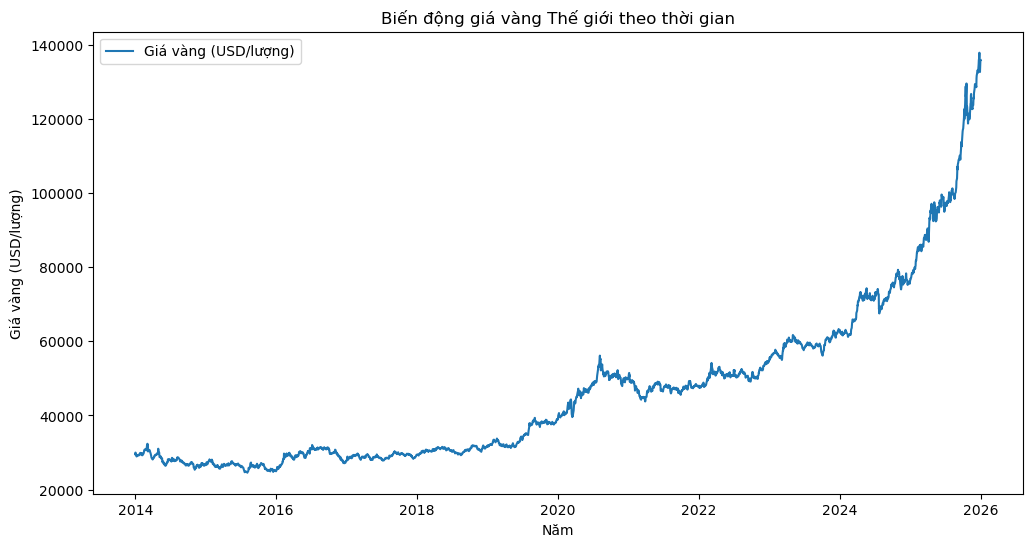

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Price'], label='Giá vàng (USD/lượng)')
plt.title('Biến động giá vàng Thế giới theo thời gian')
plt.xlabel('Năm')
plt.ylabel('Giá vàng (USD/lượng)')
plt.legend()
plt.show()

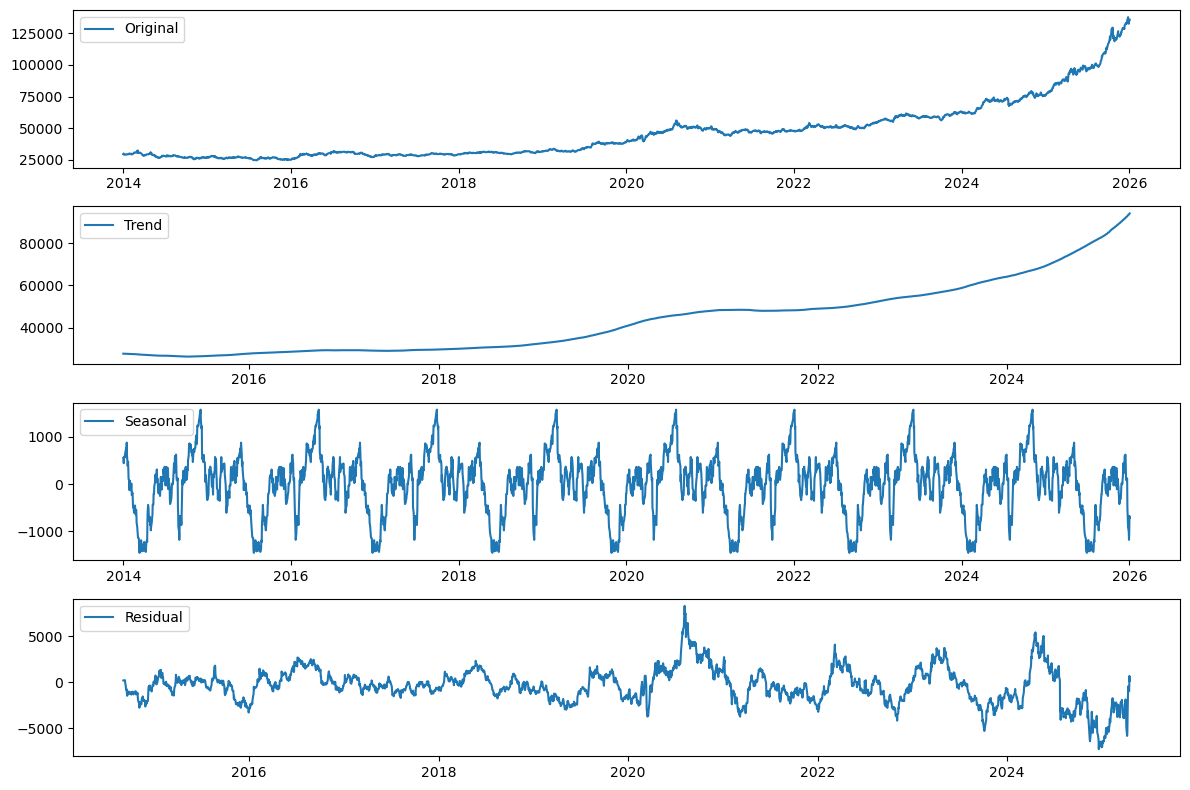

In [12]:
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
# Kiểm tra tính dừng của chuỗi thời gian bằng ADF test
from statsmodels.tsa.stattools import adfuller

decomposition = seasonal_decompose(df['Price'], model='additive', period=365)
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid
plt.figure(figsize=(12, 8))
plt.subplot(411)
plt.plot(df['Price'], label='Original')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonal, label='Seasonal')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(residual, label='Residual')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()



In [14]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# chia dữ liệu 7 3
train = df['Price'][:int(0.8*len(df))]
test = df['Price'][int(0.8*len(df)):]
print(f"Train size: {len(train)}, Test size: {len(test)}")

Train size: 2483, Test size: 621


MSE 8742340.641954202


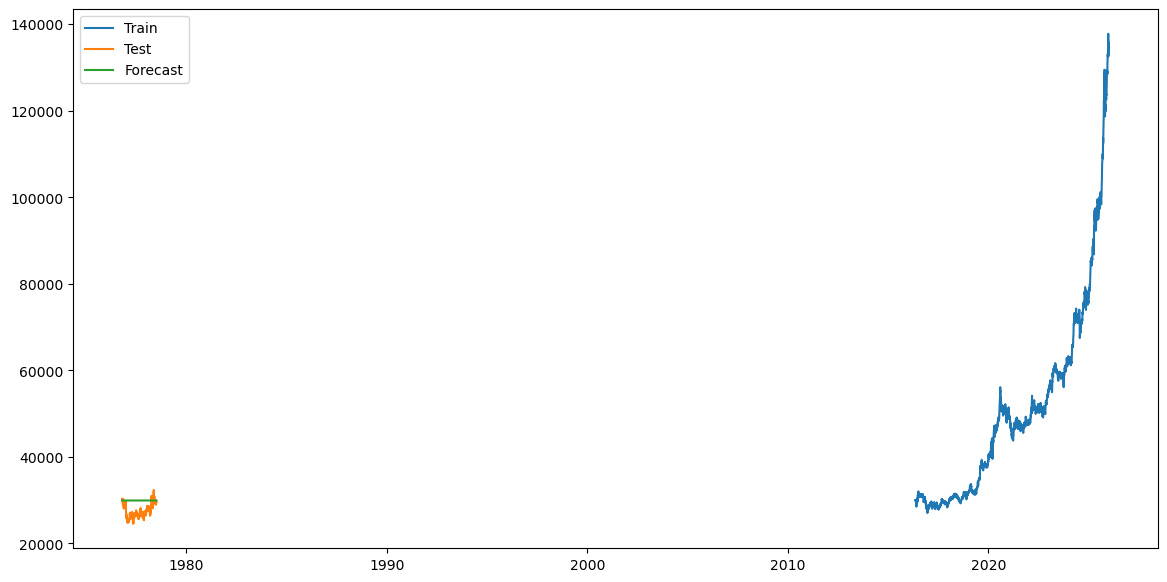

In [18]:
import warnings
warnings.filterwarnings("ignore")
model = ARIMA(train, order=(5, 1, 0))  # order=(p, d, q)
model_fit = model.fit()
forecast = model_fit.forecast(steps=len(test)) #Lưu ý để tránh lỗi về index khi tính MSE, chúng ta cần đảm bảo rằng index của forecast trùng với index của test
test.index = forecast.index  
mse = mean_squared_error(test, forecast)
print(f"MSE {mse}")

plt.figure(figsize=(14, 7));
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(forecast, label='Forecast')
plt.legend()
plt.show()

In [ ]:
# Nhận xét về kết quả dự báo:

## Về mô hình ARIMA:
### Đây là một mô hình đơn giản chỉ sử dụng những giá trị của quá khứ để dự báo 
### giá trị tương lai. Mô hình này có thể bắt được xu hướng dài hạn nhưng thường không thể nào
### dự báo được những biến động ngắn hạn như việc giá vàng có thể bị ảnh hưởng bởi rất nhiều yếu tố 
### như tình hình kinh tế,.....
## Với kết quả MSE, ta có thể thấy rằng đây là một giá trị khá lớn, điều này cho thấy rằng
## mô hình ARIMA đã không dự báo được chính xác giá vàng trong tập test.T

# ==> Cần phải thử nghiệm với các mô hình khác